### Installing the Libraries

In [1]:
# for basic mathematics operation
import numpy as np
# for dataframe manipulations
import pandas as pd

# for Data Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

# for data analysis
!pip install dabl
import dabl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 6.1 MB/s eta 0:00:00


### Reading the Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Mall Customers/Mall_Customers.csv')
data.shape

(200, 5)

In [4]:
# lets check the head of the data
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# lets check the tail of the data
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


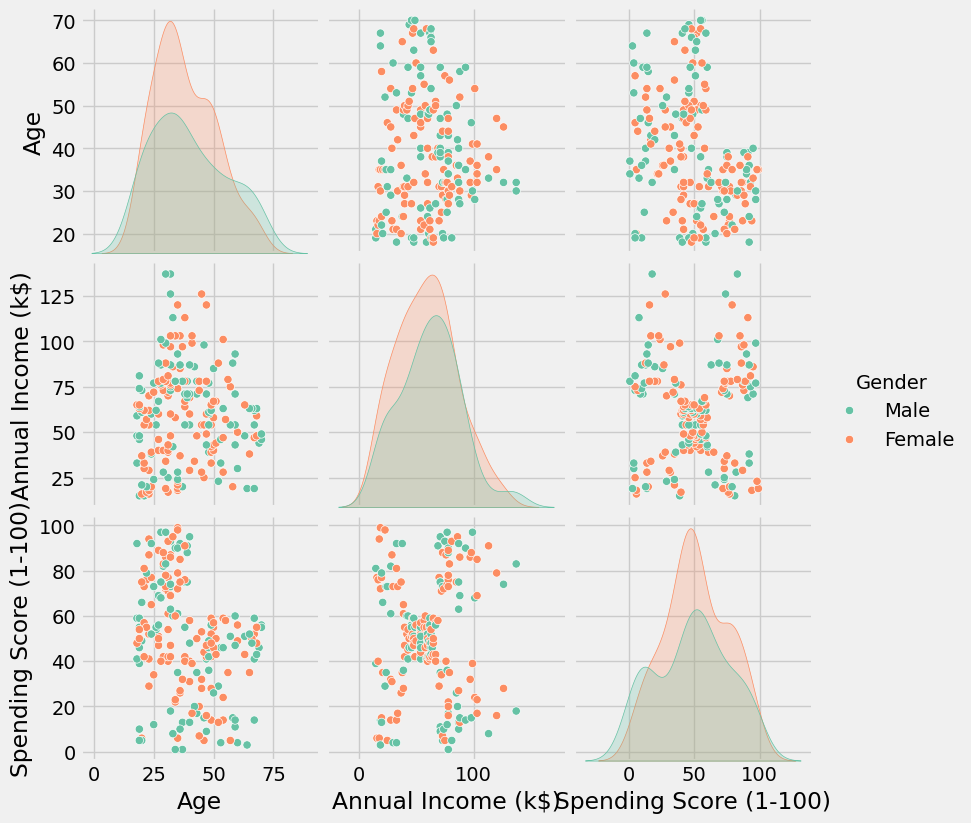

In [6]:
# lets get the pairplot for the data
# Select only the useful features for analysis
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']
sns.pairplot(data[features],hue='Gender',palette='Set2',diag_kind='kde',height=2.8)
plt.show()

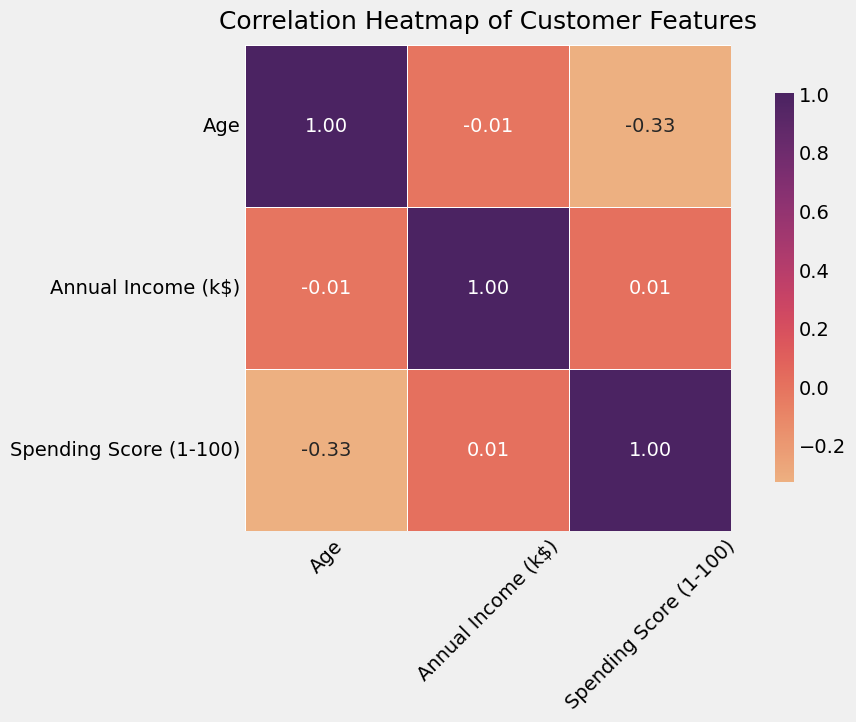

In [7]:
# lets check the Correlation Heat Map of the Data
plt.figure(figsize=(10, 6))

# Remove CustomerID because it adds fake correlation
corr = data.drop(columns=['CustomerID', 'Gender']).corr()

sns.heatmap(corr,annot=True,cmap='flare', linewidths=.5,fmt='.2f',square=True,cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap of Customer Features', fontsize=18, pad=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


Target looks like regression


/usr/local/lib/python3.12/dist-packages/dabl/plot/supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()


[<Axes: title={'center': 'Target distribution'}, xlabel='Spending Score (1...', ylabel='frequency'>,
 array([[<Axes: title={'center': 'F=-3.45E-01'}, xlabel='Age', ylabel='Spending Score (1...'>,
         <Axes: title={'center': 'F=7.84E-03'}, xlabel='Annual Income (k$)'>]],
       dtype=object),
 array([[<Axes: title={'center': 'F=9.63E-02'}, xlabel='Spending Score (1-100)', ylabel='Gender'>]],
       dtype=object)]

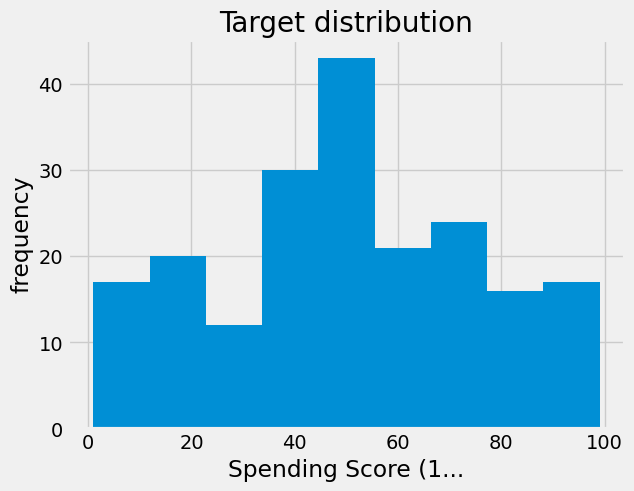

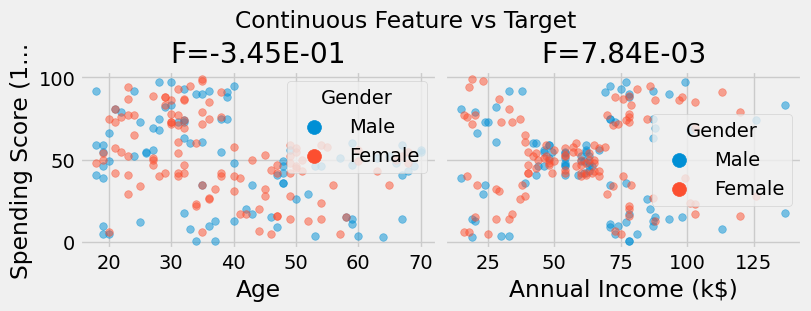

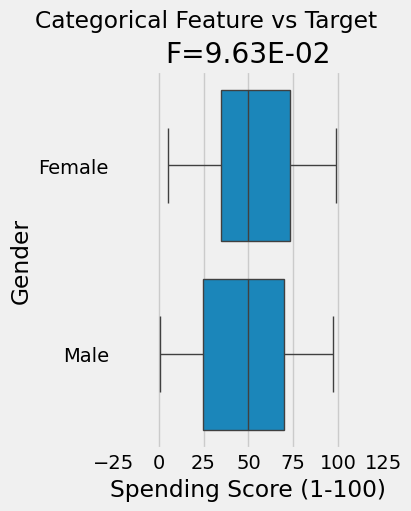

In [8]:
# lets analyze the data with respect to Spending Score

target = 'Spending Score (1-100)'

dabl.plot(data, target_col=target)


Target looks like regression


/usr/local/lib/python3.12/dist-packages/dabl/plot/supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()


[<Axes: title={'center': 'Target distribution'}, xlabel='Annual Income (k$)', ylabel='frequency'>,
 array([[<Axes: title={'center': 'F=1.98E-02'}, xlabel='Age', ylabel='Annual Income (k$)'>,
         <Axes: title={'center': 'F=7.84E-03'}, xlabel='Spending Score (1-100)'>]],
       dtype=object),
 array([[<Axes: title={'center': 'F=0.00E+00'}, xlabel='Annual Income (k$)', ylabel='Gender'>]],
       dtype=object)]

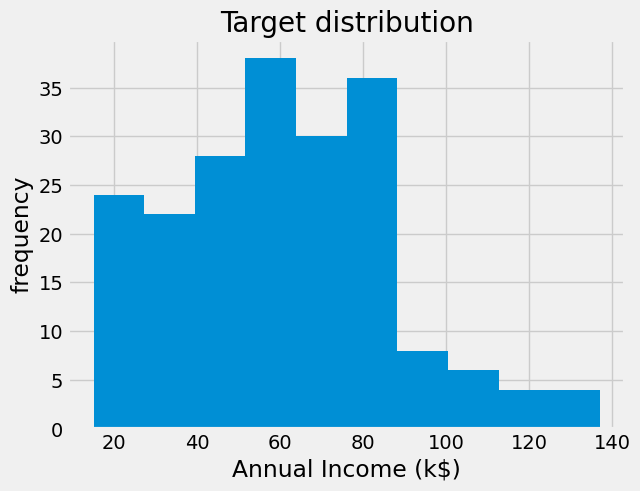

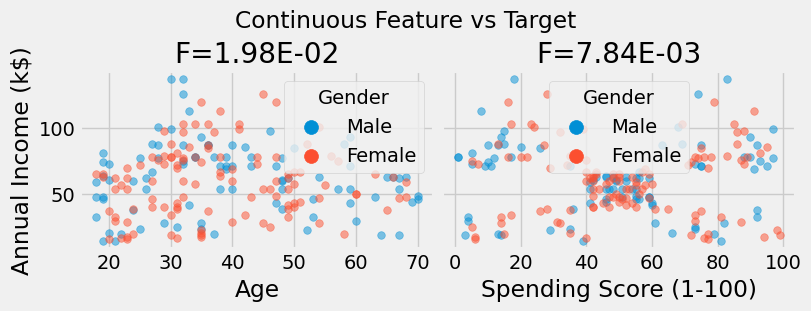

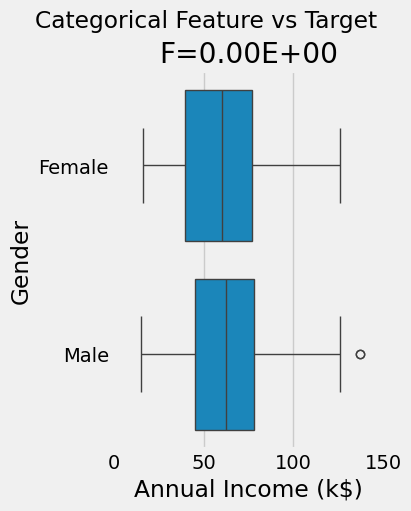

In [9]:
# lets analyze the data with respect to Annual Income
target = 'Annual Income (k$)'

dabl.plot(data, target_col=target)

## Descriptive Statistics

In [10]:
# describing the data
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
# describing the categorical data
data.describe(include = 'object')

,Gender
count,200
unique,2
top,Female
freq,112


In [12]:
# checking if there is any NULL data
data.isnull().any().any()

np.False_

## Data Visualization

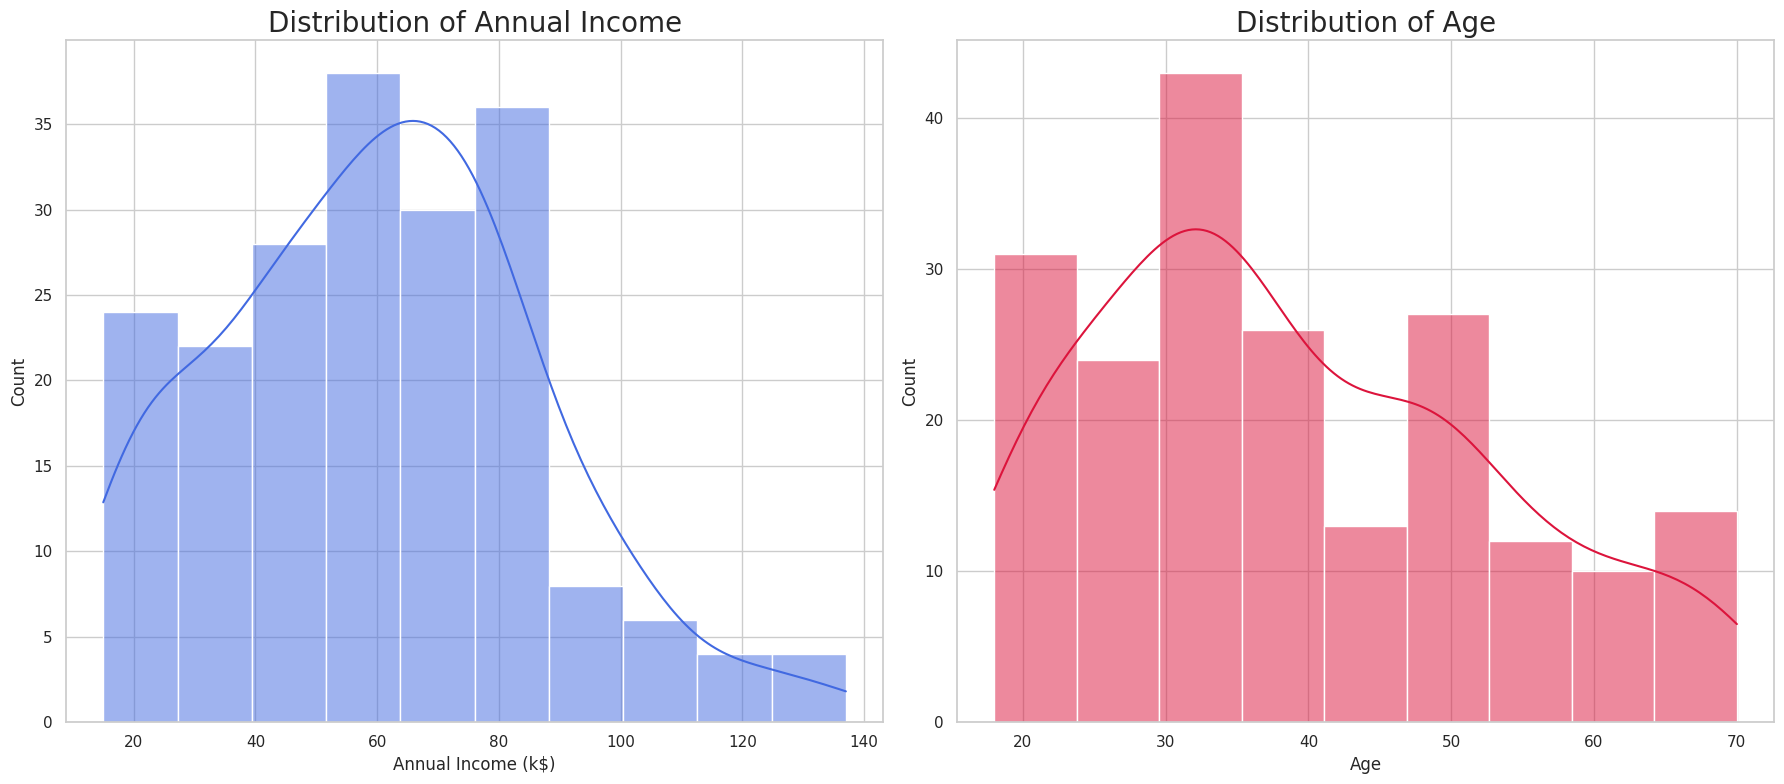

In [13]:
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.histplot(ax=axes[0], data=data, x='Annual Income (k$)', kde=True, color='royalblue')
axes[0].set_title('Distribution of Annual Income', fontsize=20)

sns.histplot(ax=axes[1], data=data, x='Age', kde=True, color='crimson')
axes[1].set_title('Distribution of Age', fontsize=20)

plt.tight_layout()
plt.show()


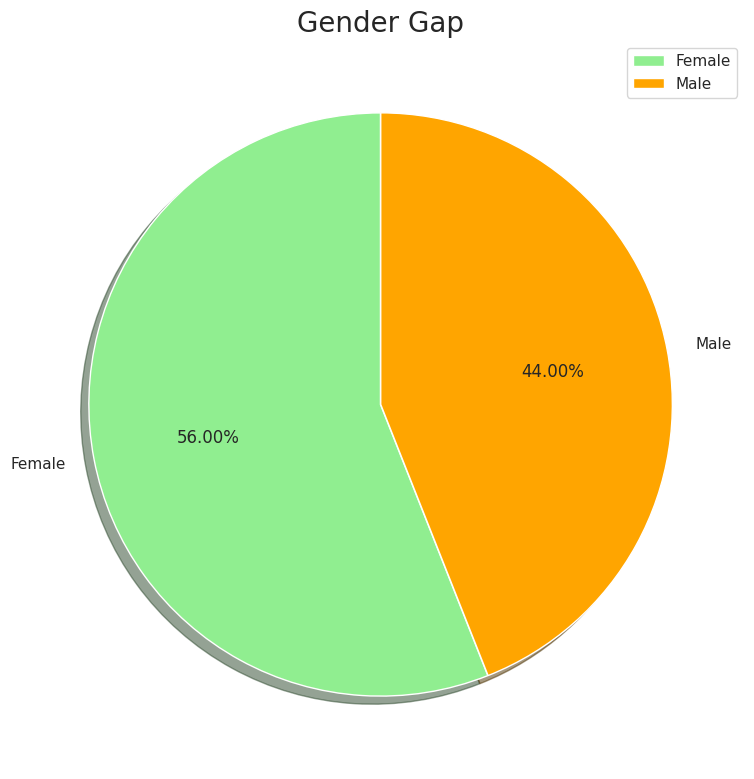

In [14]:
labels = ['Female', 'Male']
size = data['Gender'].value_counts()
colors = ['lightgreen', 'orange']
explode = [0, 0.001]

plt.rcParams['figure.figsize'] = (9, 9)
plt.pie(size, colors = colors, explode = explode, labels = labels, shadow = True, startangle = 90, autopct = '%.2f%%')
plt.title('Gender Gap', fontsize = 20)
plt.legend()
plt.show()

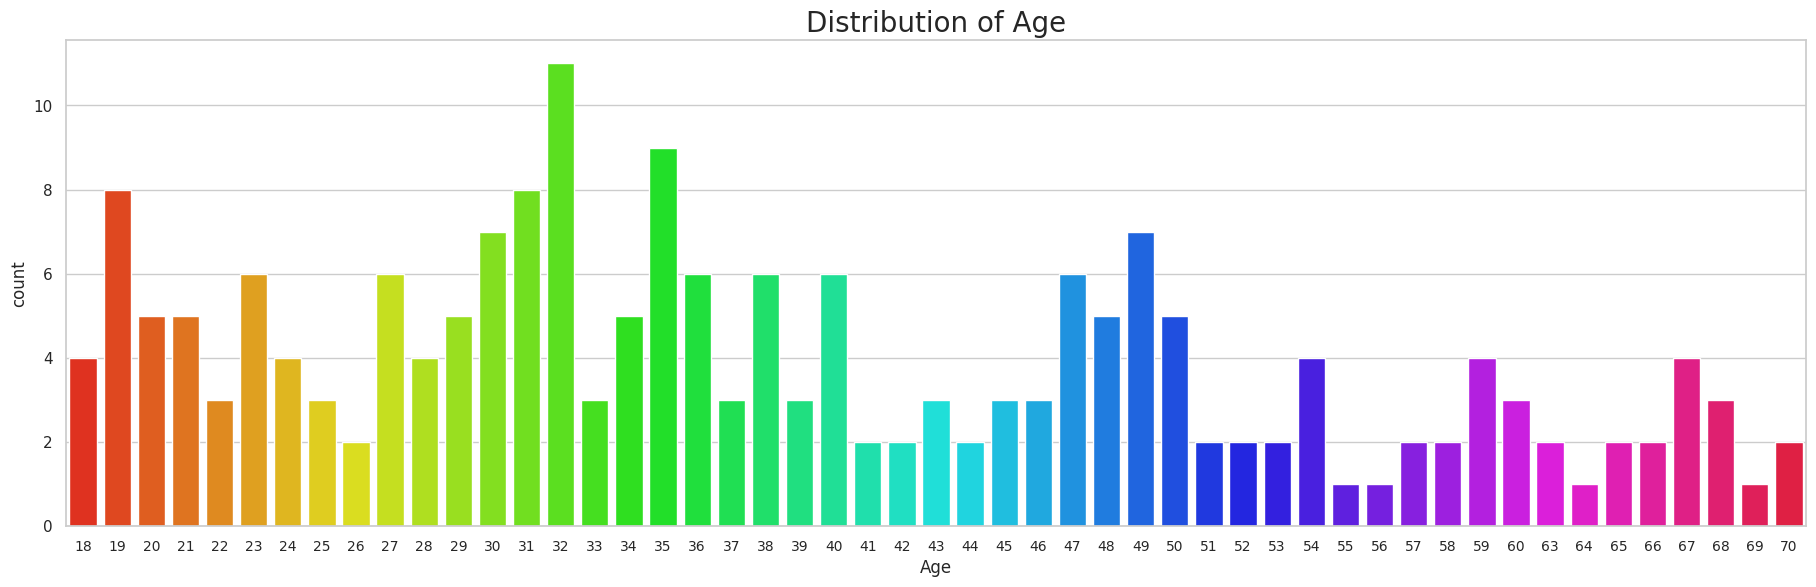

In [15]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Age', data=data, palette='hsv')

plt.xticks( fontsize=10)
plt.title('Distribution of Age', fontsize=20)
plt.show()


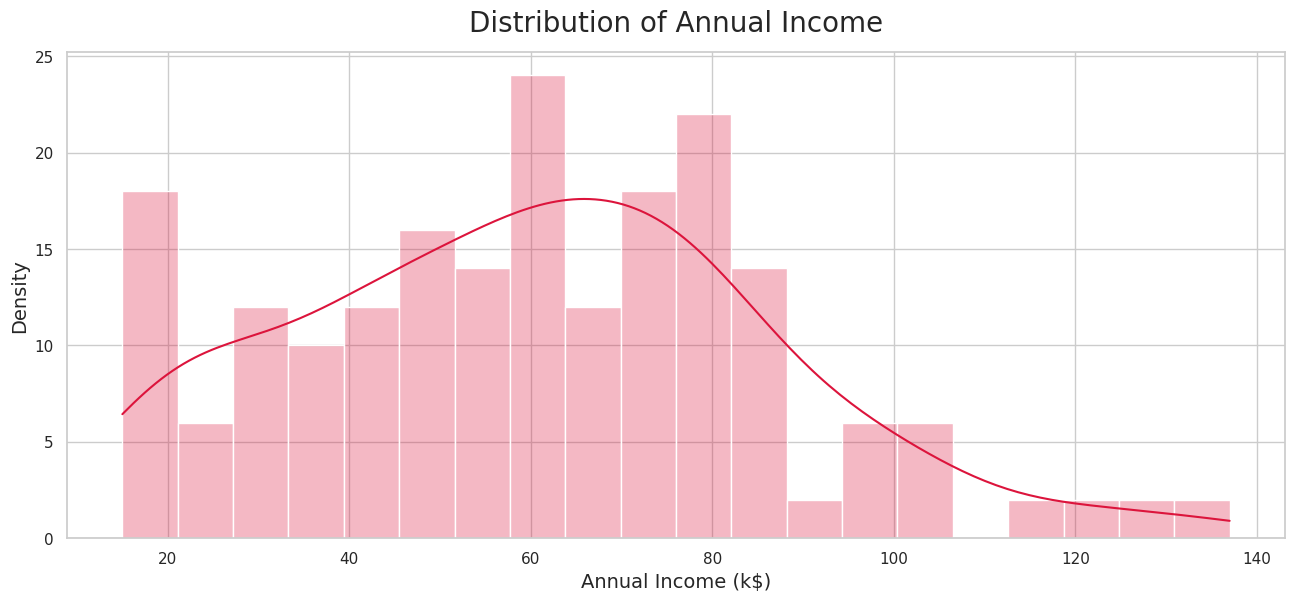

In [16]:
# lets check the sitribution of Annual Income
plt.figure(figsize=(14, 6))

sns.histplot(data['Annual Income (k$)'], bins=20,kde=True,color='crimson',alpha=0.3  ## transparent bars
             )

plt.title('Distribution of Annual Income', fontsize=20, pad=15)
plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.show()

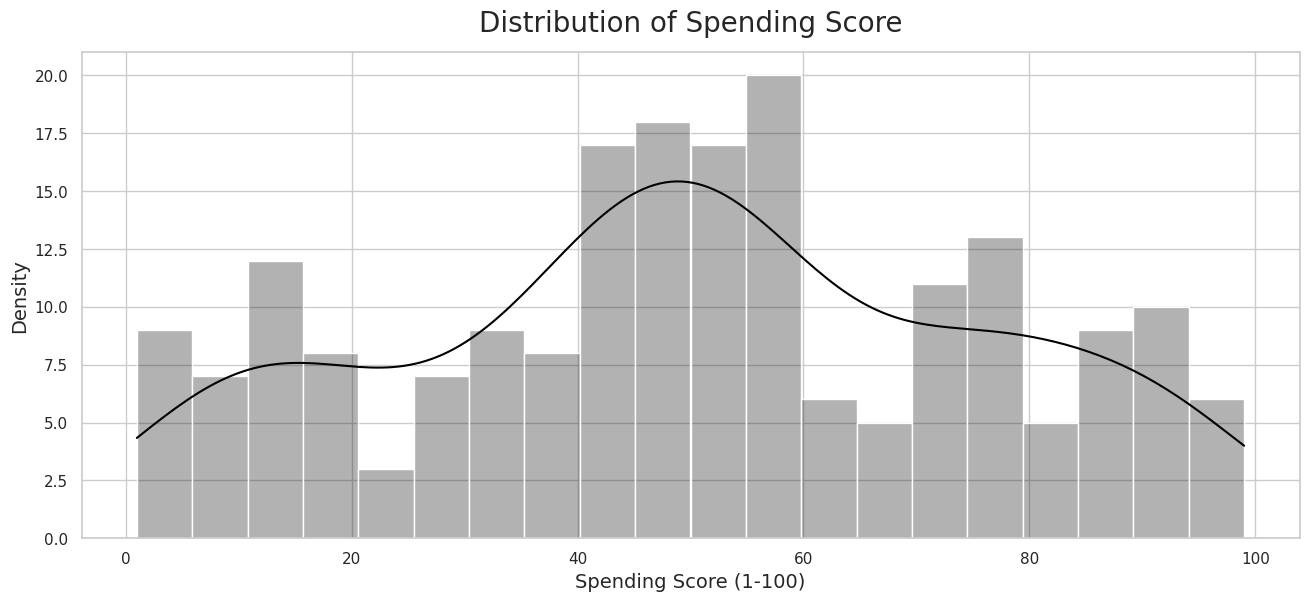

In [17]:
# lets check the distribution of Spending Score
plt.figure(figsize=(14, 6))

sns.histplot(data['Spending Score (1-100)'] ,bins=20,kde=True,color='black',alpha=0.3)
plt.title('Distribution of Spending Score', fontsize=20, pad=15)
plt.xlabel('Spending Score (1-100)', fontsize=14)
plt.ylabel('Density', fontsize=14)


plt.show()

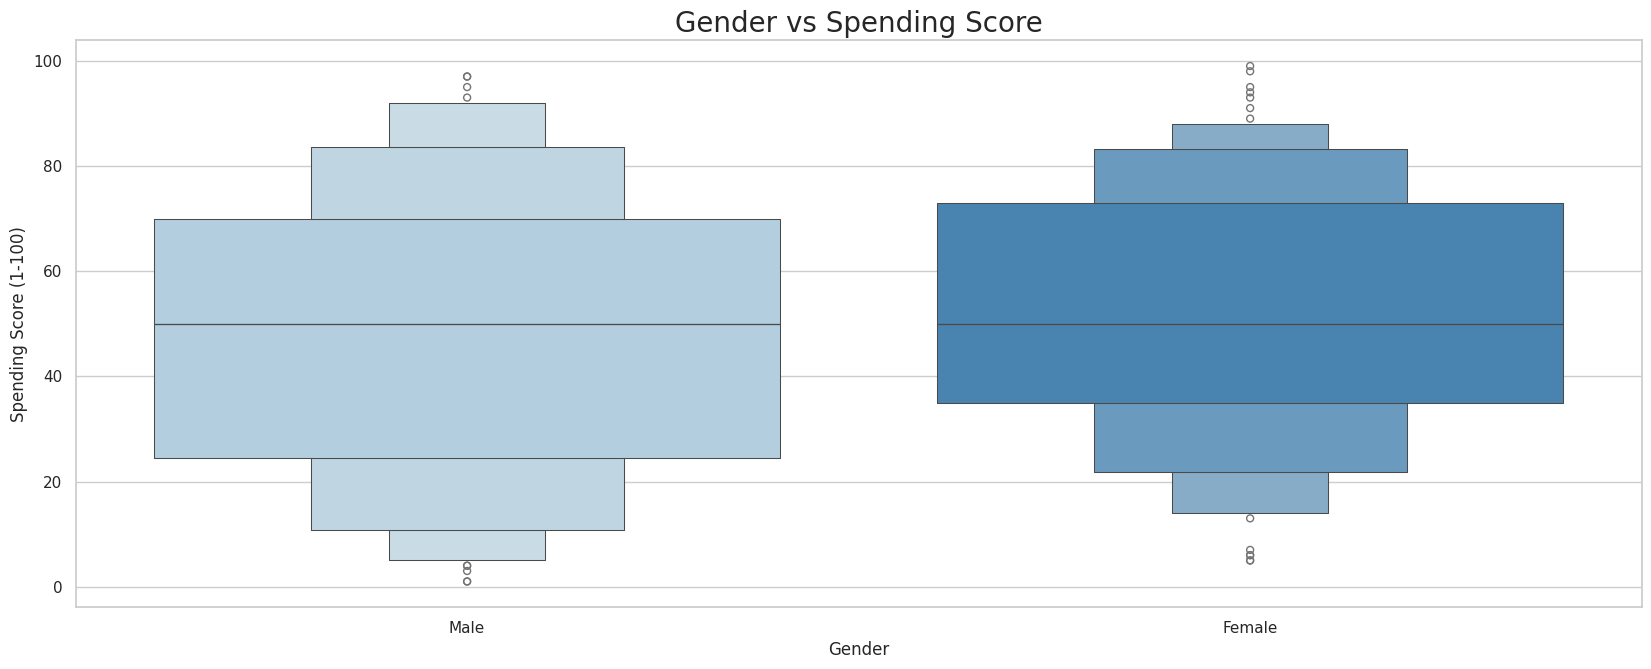

In [18]:
#  Gender vs Spendscore
plt.rcParams['figure.figsize'] = (18, 7)
sns.boxenplot(x=data['Gender'], y=data['Spending Score (1-100)'], palette = 'Blues')
plt.title('Gender vs Spending Score', fontsize = 20)
plt.show()


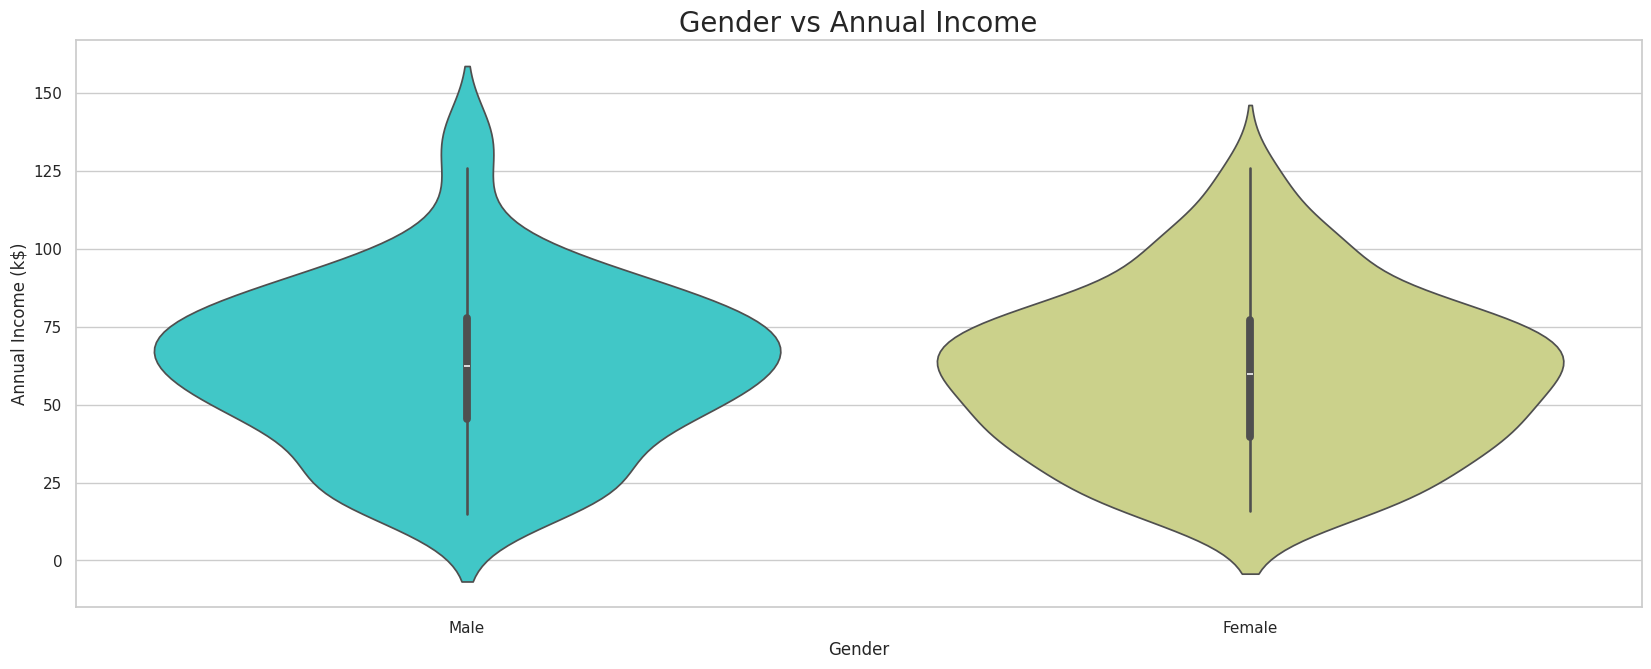

In [19]:
## Gender vs Annual Income

plt.rcParams['figure.figsize'] = (18, 7)
sns.violinplot(x=data['Gender'], y=data['Annual Income (k$)'], palette = 'rainbow')
plt.title('Gender vs Annual Income', fontsize = 20)
plt.show()

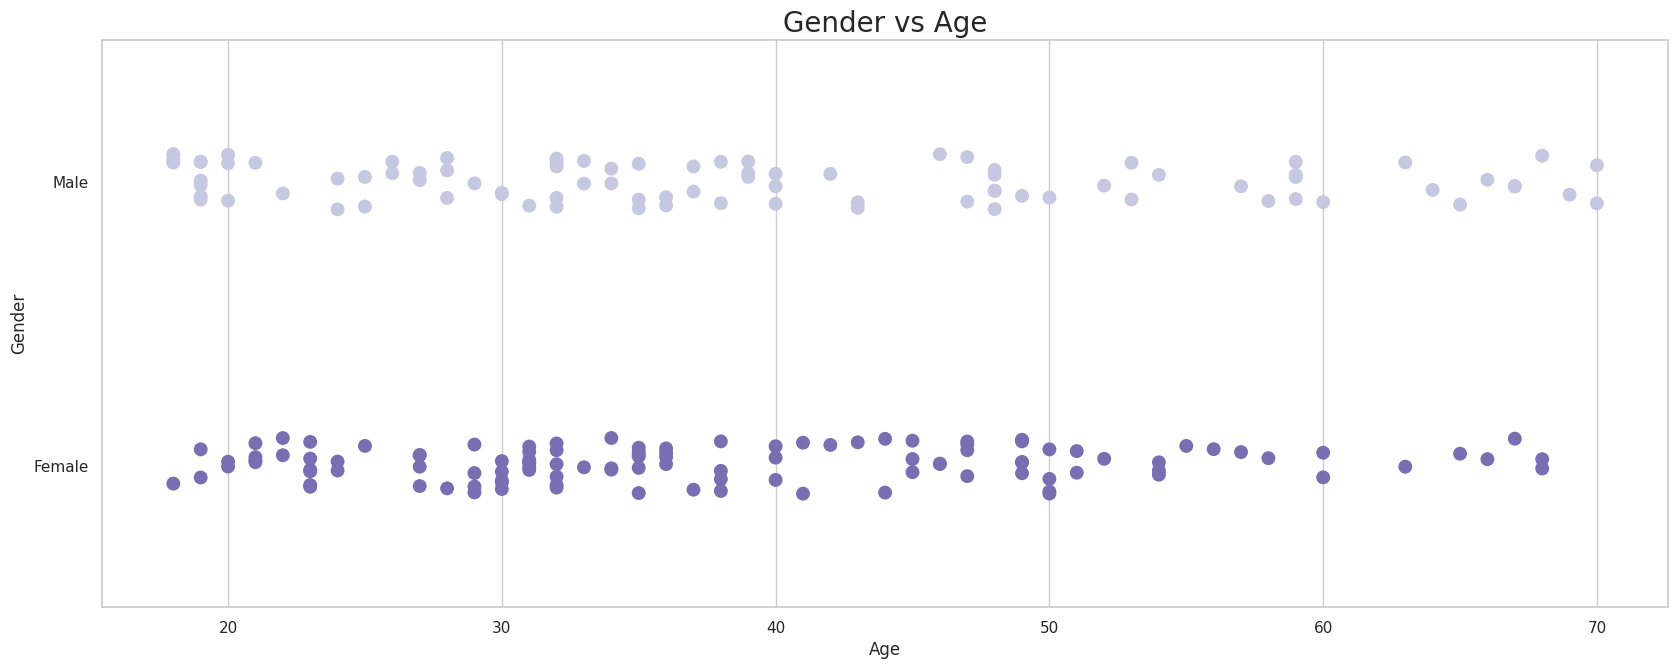

In [20]:
# Gender vs Age
plt.rcParams['figure.figsize'] = (18, 7)
sns.stripplot(y=data['Gender'], x=data['Age'], palette = 'Purples', size = 10)
plt.title('Gender vs Age', fontsize = 20)
plt.show()

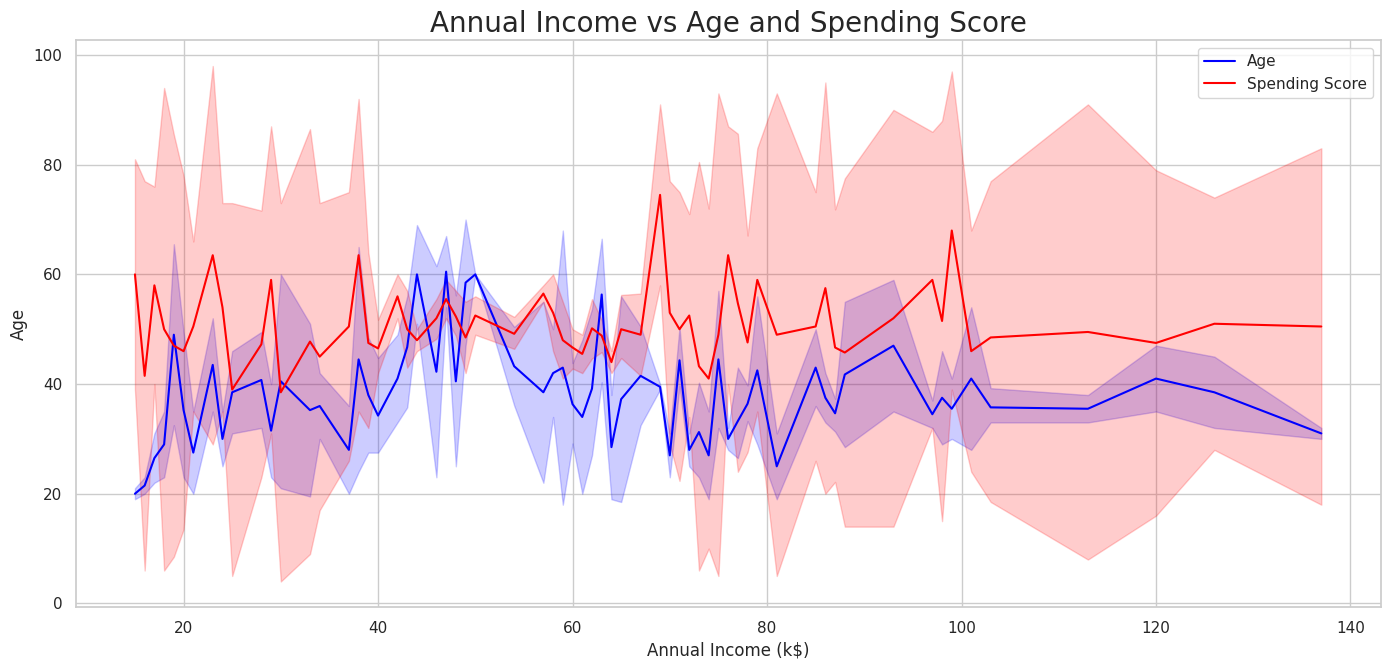

In [21]:
# Annual Income vs Age and Spending Score

plt.figure(figsize=(15, 7))

sns.lineplot(x='Annual Income (k$)', y='Age', data=data, label='Age', color='blue')
sns.lineplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=data, label='Spending Score', color='red')

plt.title('Annual Income vs Age and Spending Score', fontsize=20)
plt.show()


## Clustering Analysis

In [22]:
# we want to perform clusters of Customers who share similar behaviour for that lets select the columns
# Spending score, and Annual Income

# lets import the warnings library so that we can avoid warnings
import warnings
warnings.filterwarnings('ignore')

# Lets select the Spending score, and Annual Income Columns from the Data
x = data.loc[:, ['Spending Score (1-100)', 'Annual Income (k$)']].values

# let's check the shape of x
print(x.shape)

(200, 2)


In [23]:
# lets also check the data, which we are going to use for the clustering analysis
x_data  = pd.DataFrame(x)
x_data.head()
# where o->Spending Score, and 1->Annual Income


,0,1
0,39,15
1,81,15
2,6,16
3,77,16
4,40,17


## Kmeans Algorithm

**The Elbow Method to find the No. of Optimal Clusters**

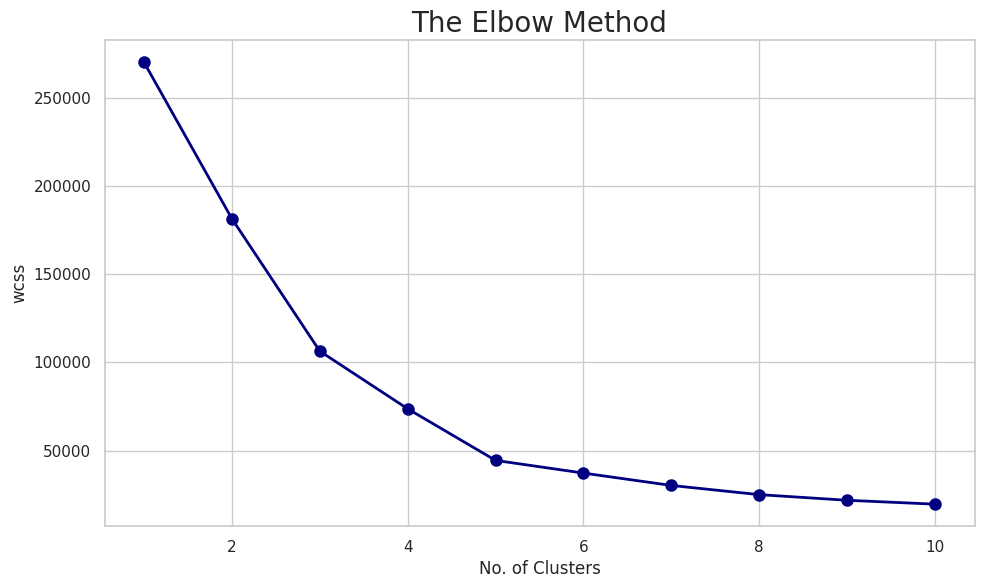

In [24]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(range(1, 11), wcss ,marker='o', linestyle='-', linewidth=2, markersize=8, color='navy')
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')
plt.show()

**Visualizaing the Clusters**

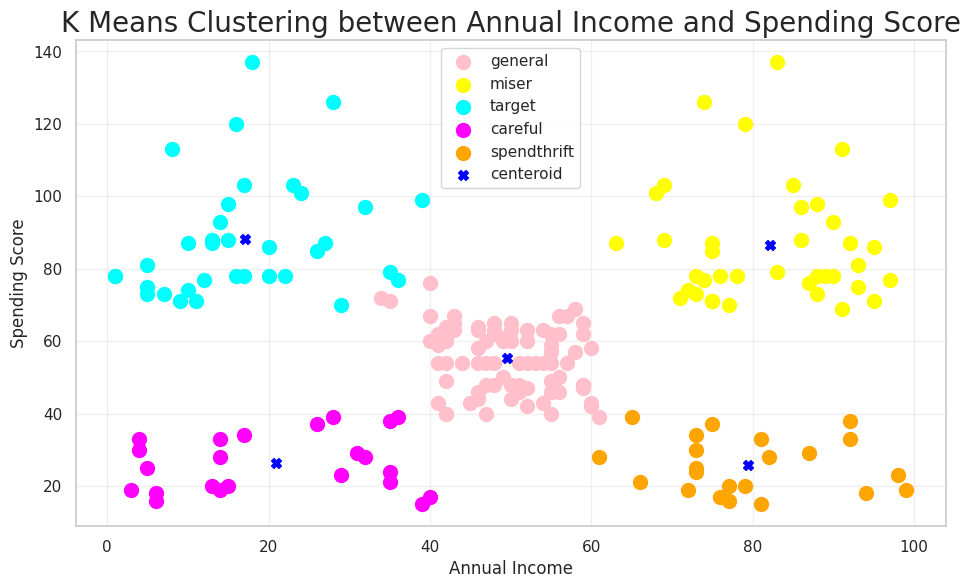

In [25]:
# lets visualize these clusters


km = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_means = km.fit_predict(x)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s = 100, c = 'pink', label = 'general')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s = 100, c = 'yellow', label = 'miser')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s = 100, c = 'cyan', label = 'target')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s = 100, c = 'magenta', label = 'careful')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s = 100, c = 'orange', label = 'spendthrift')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], s = 50, c = 'blue',marker='X' , label = 'centeroid')


plt.title('K Means Clustering between Annual Income and Spending Score', fontsize = 20)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Clustering between Age and Spending Score

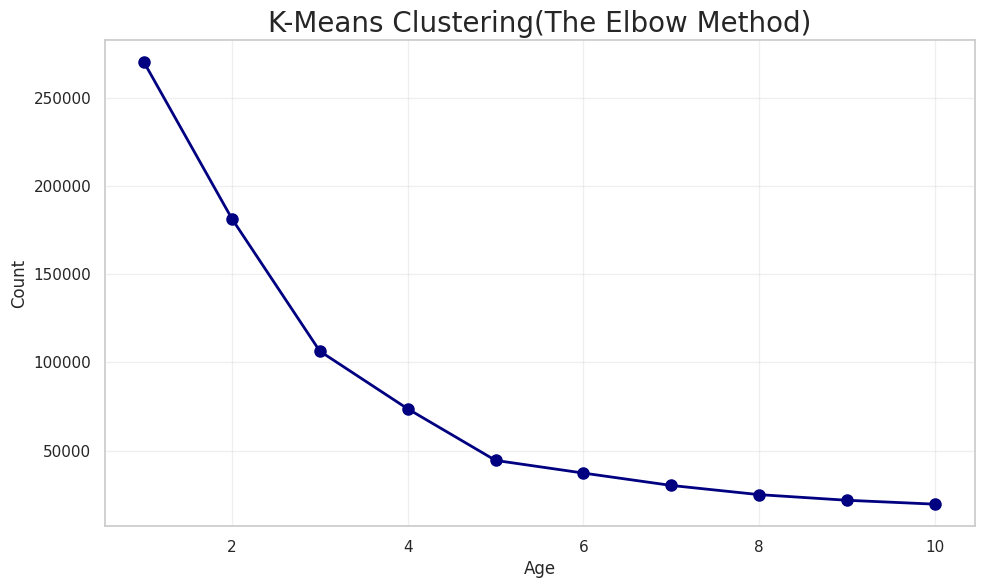

In [26]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(range(1, 11), wcss,marker='o', linestyle='-', linewidth=2, markersize=8, color='navy')
plt.title('K-Means Clustering(The Elbow Method)', fontsize = 20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

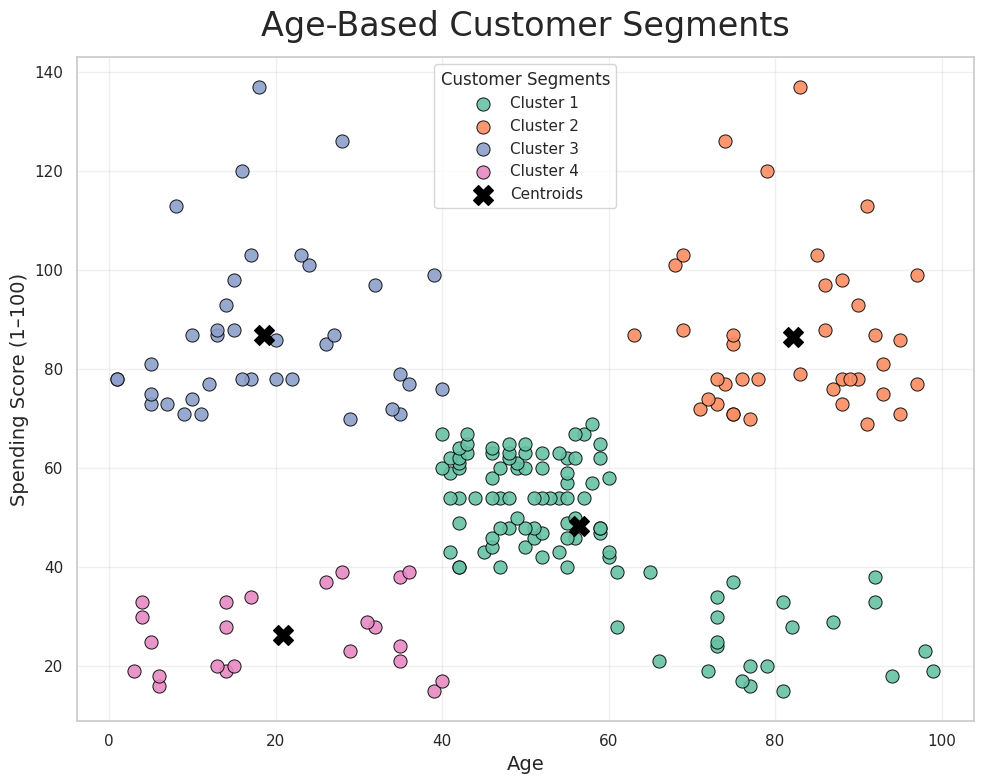

In [27]:

# Fit KMeans
kmeans = KMeans(n_clusters=4,init='k-means++',max_iter=300,n_init=10,random_state=0)
ymeans = kmeans.fit_predict(x)

# Modern color palette
colors = sns.color_palette("Set2", 4)

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

plt.title("Age-Based Customer Segments", fontsize=24, pad=15)

# Plot each cluster
for cluster in range(4):
    plt.scatter(x[ymeans == cluster, 0],x[ymeans == cluster, 1],s=90,color=colors[cluster],edgecolor="black",linewidth=0.7,alpha=0.9,label=f"Cluster {cluster+1}"
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X',
    c='black',
    label='Centroids'
)

plt.xlabel("Age", fontsize=14)
plt.ylabel("Spending Score (1–100)", fontsize=14)

plt.legend(title="Customer Segments", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
